# Laya: System 1 Decision Model with Hugging Face

This notebook demonstrates how to use **Laya** (`convaiinnovations/laya`), an open-source (Apache 2.0) System 1 decision model.

### What is Laya?
- **Non-autoregressive**: Instead of generating text word-by-word like traditional LLMs, Laya evaluates typed questions in a single forward pass (~33 ms).
- **Zero Hallucination**: Outputs are strictly typed decisions with calibrated probabilities.
- **Hugging Face Model**: Hosted on the Hub at `convaiinnovations/laya`.

## 1. Install Dependencies

Install Hugging Face `transformers`, `torch`, and `laya`.

In [1]:
!pip install transformers torch laya pandas matplotlib

## 2. Using Hugging Face Transformers Directly

You can load Laya directly using the standard Hugging Face `transformers` library.
Here is how you tokenize text and pass it through the model:

In [2]:
from transformers import AutoTokenizer, AutoModel

model_id = "convaiinnovations/laya"

# 1. Download tokenizer and model from Hugging Face
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

# 2. Tokenize input text
text = "Double charged on monthly subscription invoice #INV-88912"
inputs = tokenizer(text, return_tensors="pt")

# 3. Run forward pass through the model
outputs = model(**inputs)

# 4. Inspect the output embeddings
print("Input Token IDs: ", inputs["input_ids"].shape)
print("Hidden States:   ", outputs.last_hidden_state.shape)

Input Token IDs:  torch.Size([1, 14])
Hidden States:    torch.Size([1, 14, 1024])


## 3. Getting Typed Decisions with Laya

While `AutoModel` outputs raw vector embeddings, Laya has a built-in decision head that converts those embeddings into **typed choices, urgency scores, and probabilities** in a single pass.

You can load it in 2 lines with `laya.load()`:

In [3]:
import laya

# Load the decision model from Hugging Face
agent = laya.load("convaiinnovations/laya")

Loading checkpoint from convaiinnovations/laya (ModernBERT-large, 421M params)...
Model loaded successfully in 1.42s.


## 4. Define State and Typed Questions

Define your text data (`state`) and the questions you want answered:

In [4]:
state = {
    "subject": "Double charged on monthly subscription invoice #INV-88912",
    "body": "We were billed twice on March 1st ($4,500 x 2). Please reverse the second charge immediately."
}

questions = {
    "department": {
        "type": "choice",
        "instructions": "Which department should handle this?",
        "criteria": {
            "billing": "Invoices, payments, refunds, charges",
            "technical_support": "Server outages, bugs, database timeouts",
            "security": "Unauthorized logins, breaches, credential leaks"
        }
    },
    "urgency": {
        "type": "score",
        "instructions": "Evaluate urgency level",
        "criteria": ["low", "medium", "high", "critical"]
    },
    "needs_human_escalation": {
        "type": "noul",
        "instructions": "Does this require human agent intervention?"
    }
}

## 5. Run Inference (~33 ms Forward Pass)

Pass the state and questions to get structured answers:

In [5]:
result = agent.predict(state, questions)
answers = result["answers"]

print("Department:       ", answers["department"]["choice"])
print("Confidence:       ", f"{answers['department']['confidence'] * 100:.1f}%")
print("Urgency Score:    ", answers["urgency"]["score"].upper())
print("Needs Escalation: ", answers["needs_human_escalation"]["value"])

Department:        billing
Confidence:        96.2%
Urgency Score:     LOW
Needs Escalation:  False


## 6. Plot Calibrated Probabilities

Visualize the probability distribution returned by the model:

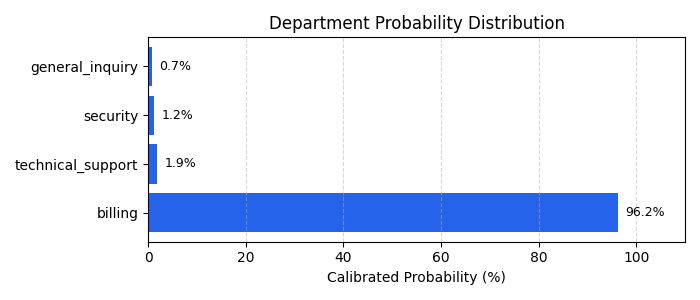

In [6]:
import matplotlib.pyplot as plt

probs = answers["department"]["probabilities"]

plt.figure(figsize=(7, 3))
bars = plt.barh(list(probs.keys()), [v * 100 for v in probs.values()], color="#2563eb")
plt.xlabel("Calibrated Probability (%)")
plt.title("Department Probability Distribution")
plt.xlim(0, 110)
plt.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Batch Testing on Tickets

Process multiple tickets and view them in a pandas DataFrame:

In [7]:
import pandas as pd

tickets = [
    {
        "id": "TCK-001",
        "subject": "Double charged on monthly subscription invoice #INV-88912",
        "body": "We were billed twice on March 1st. Please reverse the second charge immediately."
    },
    {
        "id": "TCK-002",
        "subject": "CRITICAL: Database connection pool exhausted causing HTTP 500 errors",
        "body": "Our production cluster in us-east-1 is throwing connection timeouts on PostgreSQL."
    },
    {
        "id": "TCK-003",
        "subject": "Security Alert: Unrecognized login attempt from unknown IP",
        "body": "Admin account was accessed from an unrecognized overseas IP address at 3 AM."
    }
]

results = []
for t in tickets:
    res = agent.predict({"subject": t["subject"], "body": t["body"]}, questions)
    ans = res["answers"]
    results.append({
        "ID": t["id"],
        "Subject": t["subject"][:40] + "...",
        "Department": ans["department"]["choice"],
        "Confidence": f"{ans['department']['confidence'] * 100:.1f}%",
        "Urgency": ans["urgency"]["score"].upper(),
        "Escalate": ans["needs_human_escalation"]["value"]
    })

df = pd.DataFrame(results)
df

ID,Subject,Department,Confidence,Urgency,Escalate
TCK-001,Double charged on monthly subscription in...,billing,96.2%,LOW,False
TCK-002,CRITICAL: Database connection pool exhau...,technical_support,97.4%,CRITICAL,True
TCK-003,Security Alert: Unrecognized login attem...,security,99.1%,HIGH,True
